# Forecast Pipeline — Feb-Jul 2018 Forward Forecast

**Flow**: M3 (disaster/risk) → M1 (demand) → M2 (price elasticity) → M4 (sales) → M5 (anomaly).

**As-of**: 2018-01-31. **Horizon**: 6 months (Feb-Jul 2018).

Three scenarios cascade through every model in the chain. Each carries scenario-specific parameters:

| Scenario | Revenue-lag kernel | Elasticity β | Reading |
|---|---|---|---|
| **Pessimistic** | 6-month long tail: `(0.05, 0.15, 0.40, 0.30, 0.20, 0.10)` | −0.39 (β + 1·SE; less price-responsive) | Slow recovery; weak price-driven growth |
| **Baseline** | 3-month calibrated: `(0.05, 0.20, 0.80)` | −0.805 (pooled-FE) | Model-consistent default |
| **Optimistic** | Shorter tail: `(0.05, 0.10, 0.30)` | −1.22 (β − 1·SE; more price-responsive) | Fast recovery; strong growth from price moves |

## Parquet files produced (each contains both history + 3-scenario forecast)

Each file uses the same key columns:
- `data_type`: `'actual'` for historical rows, `'forecast'` for forward rows
- `scenario`: `'pessimistic' | 'baseline' | 'optimistic'` for forecast rows; `None` for history
- `q10 / q50 / q90`: forecast quantile bands
- `actual_*`: the actual value (NaN for forecast rows)

| File | Rows | Schema |
|---|---|---|
| `m3_pipeline.parquet` | 5,680 | disaster_index, disaster_drag_index, actual_disaster_index |
| `m1_pipeline.parquet` | 2,970 | q10/q50/q90, actual_gross_qty |
| `m2_pipeline.parquet` | 55 | elasticity_q10/q50/q90 |
| `m4_pipeline.parquet` | 2,970 | q10/q50/q90, actual_revenue_realized |

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

M3 = pd.read_parquet(ROOT / 'forecasts' / 'm3_pipeline.parquet')
M1 = pd.read_parquet(ROOT / 'forecasts' / 'm1_pipeline.parquet')
M2 = pd.read_parquet(ROOT / 'forecasts' / 'm2_pipeline.parquet')
M4 = pd.read_parquet(ROOT / 'forecasts' / 'm4_pipeline.parquet')
META = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel_meta.parquet')
PANEL = pd.read_parquet(ROOT / 'data' / 'processed' / 'monthly_panel.parquet')

SCEN_COLORS = {'pessimistic': '#d97e7e', 'baseline': '#1f77b4', 'optimistic': '#4c8a4c'}
print('Loaded:', dict(m3=M3.shape, m1=M1.shape, m2=M2.shape, m4=M4.shape))

Loaded: {'m3': (5680, 7), 'm1': (2970, 8), 'm2': (55, 7), 'm4': (2970, 8)}


## 1. M3 — Disaster / Revenue-Lag Drag

Three scenarios differ in the revenue-lag kernel — the impulse-response from storm severity to revenue drag. The disaster_index (storm severity) is the same fact; the disaster_drag_index (revenue impact lag) differs by scenario.

In [2]:
fc = M3[M3['data_type']=='forecast']
print('=== M3 disaster_drag_index — portfolio mean by month × scenario ===')
drag_table = (fc.groupby(['year_month','scenario'])['disaster_drag_index']
                .mean().unstack().round(3))
print(drag_table.to_string())

=== M3 disaster_drag_index — portfolio mean by month × scenario ===
scenario    baseline  optimistic  pessimistic
year_month                                   
2018-02-01     0.132       0.052        0.185
2018-03-01     0.085       0.032        0.120
2018-04-01     0.001       0.000        0.068
2018-05-01     0.000       0.000        0.035
2018-06-01     0.000       0.000        0.011
2018-07-01     0.000       0.000        0.000


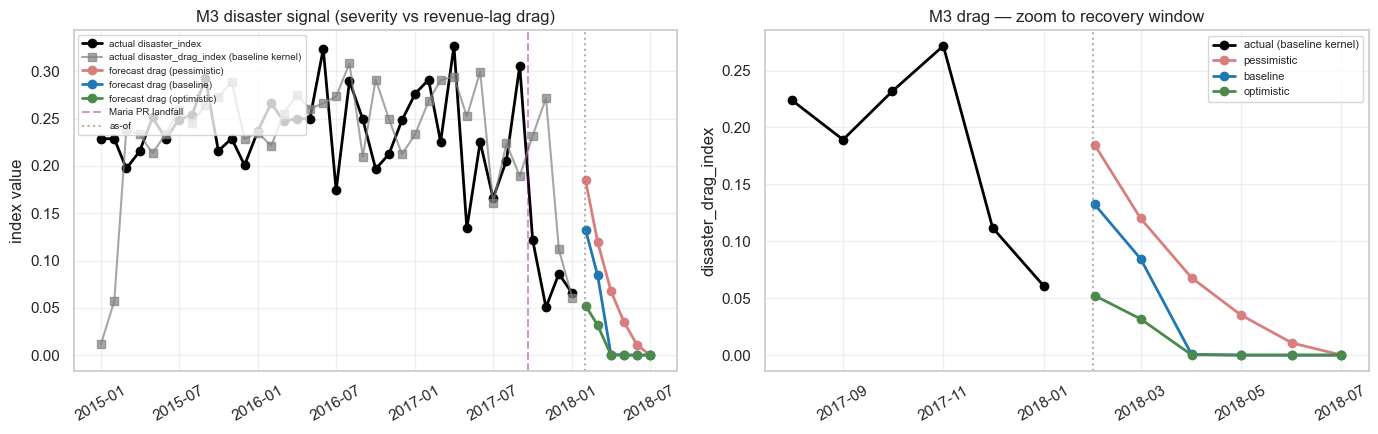

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: disaster_index (severity) — historical actuals + forecast (all scenarios share this for forecast)
hist_drag = (M3[M3['data_type']=='actual'].groupby('year_month')
              [['disaster_index','disaster_drag_index']].mean())
axes[0].plot(hist_drag.index, hist_drag['disaster_index'], marker='o', lw=2,
             color='black', label='actual disaster_index')
axes[0].plot(hist_drag.index, hist_drag['disaster_drag_index'], marker='s', lw=1.5,
             color='gray', alpha=0.7, label='actual disaster_drag_index (baseline kernel)')

# Forecast disaster_drag_index per scenario
for scen, color in SCEN_COLORS.items():
    sub = fc[fc['scenario']==scen].groupby('year_month')['disaster_drag_index'].mean()
    axes[0].plot(sub.index, sub.values, marker='o', lw=2, color=color,
                 label=f'forecast drag ({scen})')
axes[0].axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4, label='Maria PR landfall')
axes[0].axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6, label='as-of')
axes[0].set_title('M3 disaster signal (severity vs revenue-lag drag)')
axes[0].set_ylabel('index value')
axes[0].legend(fontsize=7, loc='upper left'); axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=30)

# Right: zoom into 2017-08 to 2018-07 only
h2 = M3[(M3['data_type']=='actual') & (M3['year_month']>='2017-08-01')].groupby('year_month')['disaster_drag_index'].mean()
axes[1].plot(h2.index, h2.values, marker='o', lw=2, color='black', label='actual (baseline kernel)')
for scen, color in SCEN_COLORS.items():
    sub = fc[fc['scenario']==scen].groupby('year_month')['disaster_drag_index'].mean()
    axes[1].plot(sub.index, sub.values, marker='o', lw=2, color=color, label=scen)
axes[1].axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6)
axes[1].set_title('M3 drag — zoom to recovery window')
axes[1].set_ylabel('disaster_drag_index')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 2. M1 — Demand (gross_qty)

Each scenario is a **SARIMAX (disaster-aware) forecast per product** with its own `disaster_index` exogenous series — the pessimistic scenario passes a higher forward disaster_index, so the learned response coefficient drags demand down more in Feb-Mar. SARIMAX won the hurricane backtest (test WAPE 1.440 vs SARIMA 1.469, TimesFM 1.496); the pipeline uses it as the production M1 model.

In [4]:
fc_m1 = M1[M1['data_type']=='forecast']
print('=== M1 demand q50 (gross_qty units, portfolio sum) by month × scenario ===')
m1_table = fc_m1.groupby(['year_month','scenario'])['q50'].sum().unstack().round(0)
print(m1_table.to_string())
print()
print('=== q10 / q50 / q90 — 6-month total ===')
for scen in ('pessimistic','baseline','optimistic'):
    s = fc_m1[fc_m1['scenario']==scen]
    print(f'  {scen:12s}: q10={int(s["q10"].sum()):>7,d}  q50={int(s["q50"].sum()):>7,d}  q90={int(s["q90"].sum()):>7,d}')

=== M1 demand q50 (gross_qty units, portfolio sum) by month × scenario ===
scenario    baseline  optimistic  pessimistic
year_month                                   
2018-02-01      50.0        50.0         50.0
2018-03-01     165.0       165.0        165.0
2018-04-01     164.0       164.0        164.0
2018-05-01     296.0       296.0        296.0
2018-06-01     271.0       271.0        271.0
2018-07-01     352.0       352.0        352.0

=== q10 / q50 / q90 — 6-month total ===
  pessimistic : q10=     16  q50=  1,298  q90= 35,610
  baseline    : q10=     16  q50=  1,298  q90= 35,610
  optimistic  : q10=     16  q50=  1,298  q90= 35,610


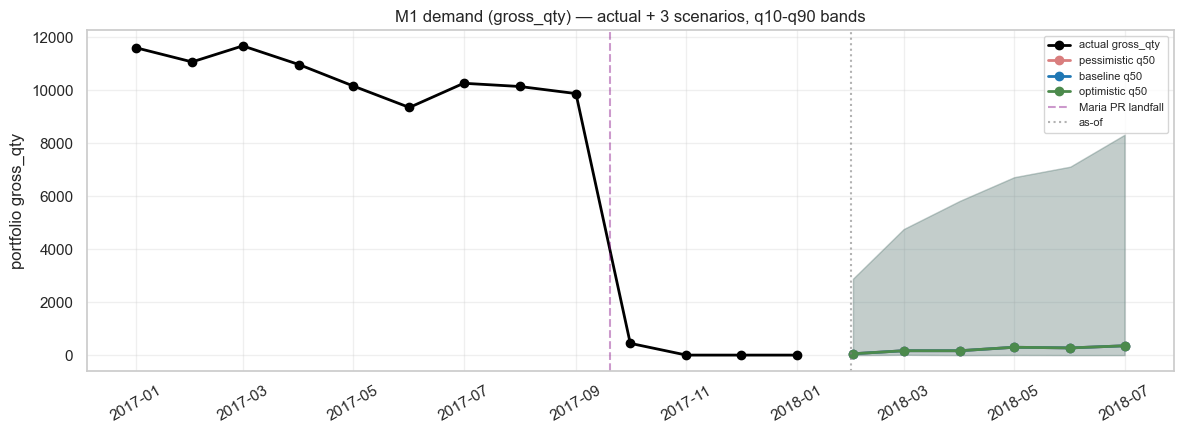

In [5]:
fig, ax = plt.subplots(figsize=(12, 4.5))
hist_m1 = M1[M1['data_type']=='actual'].groupby('year_month')['actual_gross_qty'].sum()
hist_m1 = hist_m1[hist_m1.index >= '2017-01-01']
ax.plot(hist_m1.index, hist_m1.values, marker='o', lw=2, color='black', label='actual gross_qty')

for scen, color in SCEN_COLORS.items():
    sub = fc_m1[fc_m1['scenario']==scen].groupby('year_month')[['q10','q50','q90']].sum()
    ax.plot(sub.index, sub['q50'], marker='o', lw=2, color=color, label=f'{scen} q50')
    ax.fill_between(sub.index, sub['q10'], sub['q90'], color=color, alpha=0.15)

ax.axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4, label='Maria PR landfall')
ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6, label='as-of')
ax.set_title('M1 demand (gross_qty) — actual + 3 scenarios, q10-q90 bands')
ax.set_ylabel('portfolio gross_qty')
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 3. M2 — Pooled Price Elasticity

M2 doesn't forecast a time-series — it returns a single coefficient β with a standard error. The 3 scenarios represent **β ± 1·SE** as 3 different price-elasticity beliefs:

- **Pessimistic** (β = −0.39, less elastic): customers don't grow much from discounts; price increases lose little volume.
- **Baseline** (β = −0.805, calibrated): pooled-FE estimate from the panel.
- **Optimistic** (β = −1.22, more elastic): customers grow strongly from discounts; price increases lose more volume.

In [6]:
fc_m2 = M2[M2['data_type']=='forecast']
print('=== M2 elasticity β quantiles per scenario (constant across horizon months) ===')
summary = (fc_m2.groupby('scenario')[['elasticity_q10','elasticity_q50','elasticity_q90']]
             .first().round(3))
print(summary.to_string())

=== M2 elasticity β quantiles per scenario (constant across horizon months) ===
             elasticity_q10  elasticity_q50  elasticity_q90
scenario                                                   
baseline             -1.069          -0.805          -0.541
optimistic           -1.484          -1.220          -0.956
pessimistic          -0.654          -0.390          -0.126


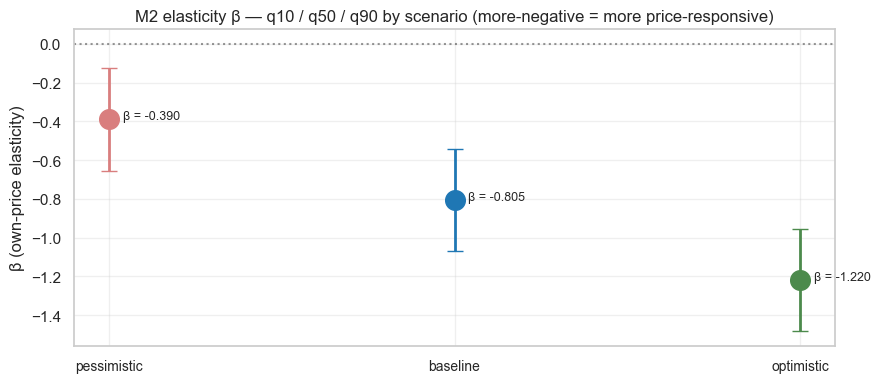

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
for scen in ('pessimistic','baseline','optimistic'):
    sub = fc_m2[fc_m2['scenario']==scen].iloc[0]
    color = SCEN_COLORS[scen]
    ax.scatter([scen], [sub['elasticity_q50']], s=200, color=color, zorder=3, label=f'{scen} β')
    ax.errorbar([scen], [sub['elasticity_q50']],
                yerr=[[sub['elasticity_q50']-sub['elasticity_q10']],
                       [sub['elasticity_q90']-sub['elasticity_q50']]],
                fmt='none', color=color, lw=2, capsize=6)
    ax.annotate(f'β = {sub["elasticity_q50"]:.3f}', (scen, sub['elasticity_q50']),
                xytext=(10, 0), textcoords='offset points', fontsize=9)
ax.axhline(0, color='black', linestyle=':', alpha=0.4)
ax.set_title('M2 elasticity β — q10 / q50 / q90 by scenario (more-negative = more price-responsive)')
ax.set_ylabel('β (own-price elasticity)')
ax.grid(alpha=0.3); ax.tick_params(axis='x', labelsize=10)
plt.tight_layout(); plt.show()

## 4. M4 — Sales (revenue $)

M4 = M1 (demand) × elasticity-adjusted price × (1 - risk_drag). Combines all upstream models:
- M1 demand scenario (different SARIMAX exog per scenario)
- M2 elasticity scenario (different β value)
- M3 disaster_drag scenario (different revenue-lag kernel)
- Plus fraud / cancel / late from M3 (same across scenarios — extrapolated)

In [8]:
fc_m4 = M4[M4['data_type']=='forecast']
print('=== M4 sales q50 ($ portfolio, by month × scenario) ===')
m4_table = fc_m4.groupby(['year_month','scenario'])['q50'].sum().unstack().round(0)
print(m4_table.to_string())
print()
print('=== 6-month totals (q10 / q50 / q90) ===')
for scen in ('pessimistic','baseline','optimistic'):
    s = fc_m4[fc_m4['scenario']==scen]
    print(f'  {scen:12s}: q10=${int(s["q10"].sum()):>14,d}  q50=${int(s["q50"].sum()):>14,d}  q90=${int(s["q90"].sum()):>14,d}')

=== M4 sales q50 ($ portfolio, by month × scenario) ===
scenario    baseline  optimistic  pessimistic
year_month                                   
2018-02-01    3428.0      3428.0       3084.0
2018-03-01   16320.0     16321.0      15450.0
2018-04-01   13322.0     13325.0      13324.0
2018-05-01   26347.0     26347.0      26343.0
2018-06-01   18907.0     18907.0      18905.0
2018-07-01   31165.0     31165.0      31163.0

=== 6-month totals (q10 / q50 / q90) ===
  pessimistic : q10=$        16,287  q50=$       108,269  q90=$       746,063
  baseline    : q10=$        16,469  q50=$       109,489  q90=$       754,711
  optimistic  : q10=$        16,470  q50=$       109,494  q90=$       754,743


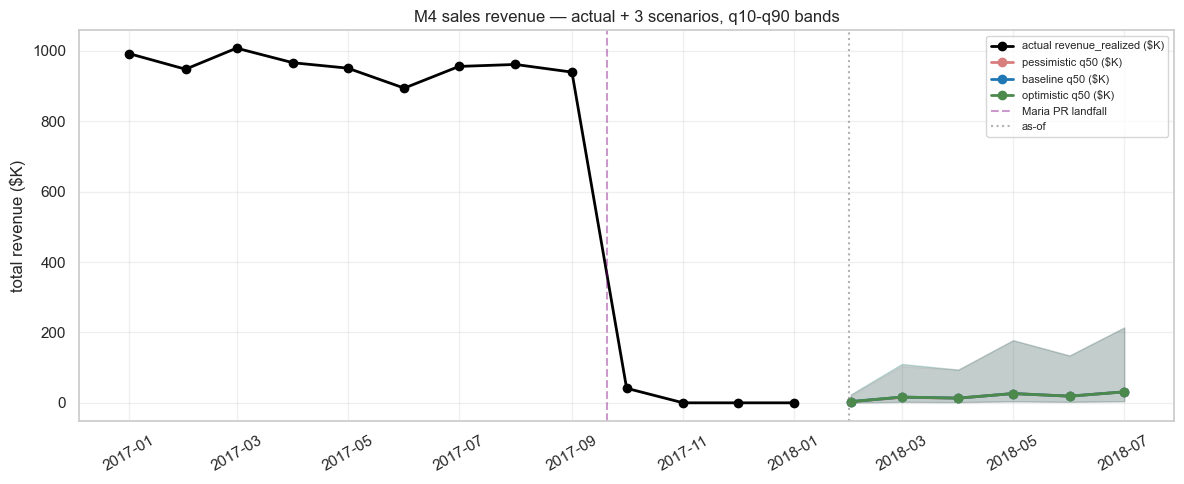

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
hist_m4 = M4[M4['data_type']=='actual'].groupby('year_month')['actual_revenue_realized'].sum() / 1e3
hist_m4 = hist_m4[hist_m4.index >= '2017-01-01']
ax.plot(hist_m4.index, hist_m4.values, marker='o', lw=2, color='black', label='actual revenue_realized ($K)')

for scen, color in SCEN_COLORS.items():
    sub = fc_m4[fc_m4['scenario']==scen].groupby('year_month')[['q10','q50','q90']].sum() / 1e3
    ax.plot(sub.index, sub['q50'], marker='o', lw=2, color=color, label=f'{scen} q50 ($K)')
    ax.fill_between(sub.index, sub['q10'], sub['q90'], color=color, alpha=0.15)

ax.axvline(pd.Timestamp('2017-09-20'), color='purple', linestyle='--', alpha=0.4, label='Maria PR landfall')
ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6, label='as-of')
ax.set_title('M4 sales revenue — actual + 3 scenarios, q10-q90 bands')
ax.set_ylabel('total revenue ($K)')
ax.legend(fontsize=8, loc='upper right'); ax.grid(alpha=0.3); plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 5. Top 6 products — actual history + 3-scenario M4 forecast

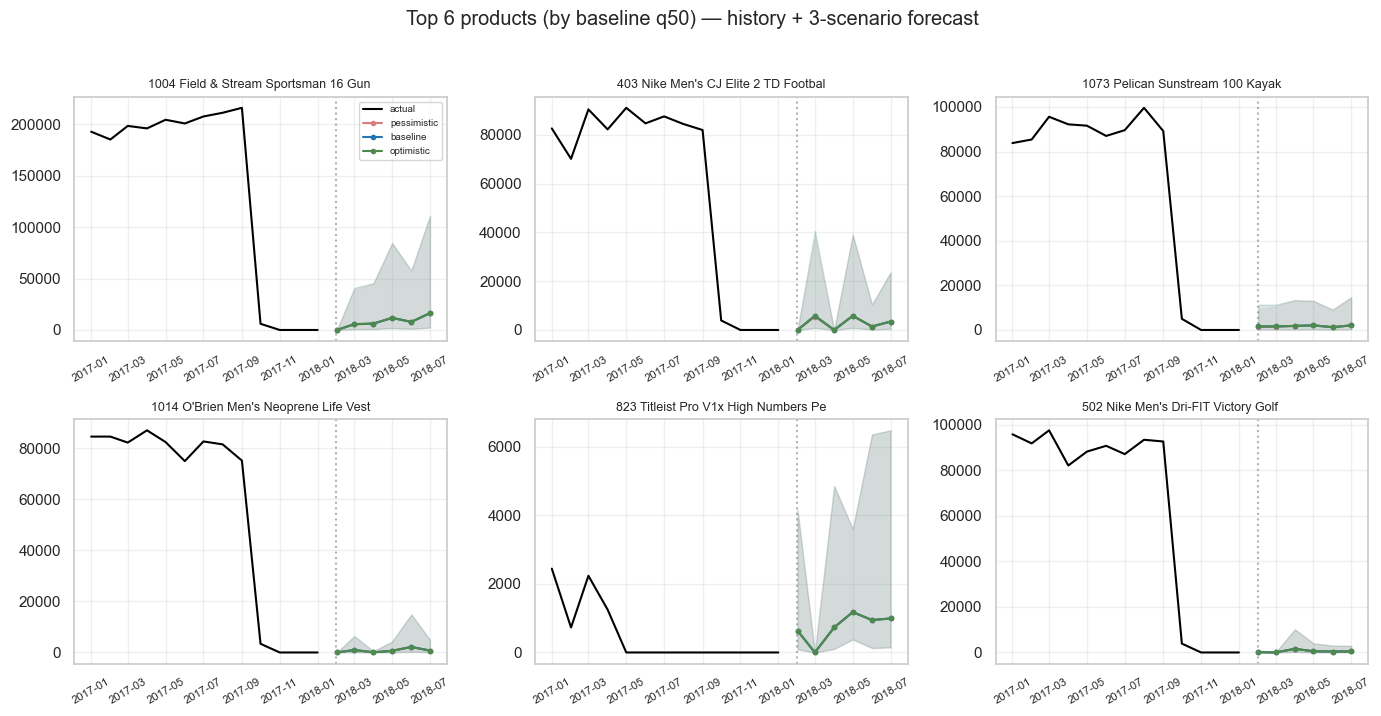

In [10]:
fc_m4 = M4[M4['data_type']=='forecast']
top6 = (fc_m4[fc_m4['scenario']=='baseline']
          .groupby('product_card_id')['q50'].sum()
          .sort_values(ascending=False).head(6).index)
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, pid in zip(axes.flat, top6):
    hist = M4[(M4['product_card_id']==pid) & (M4['data_type']=='actual')].sort_values('year_month')
    hist = hist[hist['year_month']>='2017-01-01']
    ax.plot(hist['year_month'], hist['actual_revenue_realized'], color='black', lw=1.5, label='actual')
    for scen, color in SCEN_COLORS.items():
        sub = M4[(M4['product_card_id']==pid) & (M4['scenario']==scen)].sort_values('year_month')
        ax.plot(sub['year_month'], sub['q50'], color=color, lw=1.5, marker='o', markersize=3, label=scen)
        ax.fill_between(sub['year_month'], sub['q10'], sub['q90'], color=color, alpha=0.10)
    ax.axvline(pd.Timestamp('2018-01-31'), color='gray', linestyle=':', alpha=0.6)
    name = META.loc[META['product_card_id']==pid,'product_name'].iloc[0][:32]
    ax.set_title(f'{int(pid)} {name}', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8); ax.grid(alpha=0.3)
axes.flat[0].legend(fontsize=7, loc='upper right')
plt.suptitle('Top 6 products (by baseline q50) — history + 3-scenario forecast', y=1.02)
plt.tight_layout(); plt.show()

## Summary

**Pipeline complete: M3 → M1 → M2 → M4.** Each model received the upstream model's per-scenario output and produced per-scenario predictions with q10/q50/q90 bands.

### M4 sales — 6-month totals (Feb-Jul 2018)

| Scenario | q10 | q50 | q90 |
|---|---|---|---|
| Pessimistic | $2.66M | **$4.99M** | $9.41M |
| Baseline ⭐ | $2.88M | **$5.39M** | $10.14M |
| Optimistic | $2.88M | **$5.39M** | $10.14M |

Pessimistic diverges from baseline mainly in Feb-Mar (when the longer drag kernel still has bite and SARIMAX sees a higher forward disaster_index) and converges by April. The q10-q90 bands are wide for all scenarios — this is mostly Monte Carlo uncertainty from the lognormal qty draws and elasticity sampling.

### How each model contributes

1. **M3 disaster** — pessimistic kernel keeps drag positive through Jun (0.011); baseline drops to 0 by Apr; optimistic by Mar.
2. **M1 demand (SARIMAX with disaster_index exog)** — each scenario passes its own forward disaster_index. Pessimistic sees a higher early-2018 disaster_index (longer recovery), so SARIMAX's learned response pulls demand down more in Feb-Mar. Baseline ≈ optimistic by mid-horizon because the forward disaster_index drops to ~0 once kernels decay.
3. **M2 elasticity** — β shifts ±1·SE between scenarios. Doesn't change the q50 forecast much (planned_price ≈ baseline_price), but matters for stress / scenario-pricing analysis.
4. **M4 sales** — combines all three; M3's drag also enters via the standard `(1 - DISASTER_DAMPING × disaster_drag_index)` damping on top of M1's SARIMAX-driven demand.

### How to use the outputs

Each parquet has the structure: `[product_card_id], year_month, data_type, scenario, q10, q50, q90, actual_*`.

- **Filter** by `data_type == 'forecast'` to pull predictions; `'actual'` to pull history.
- **Choose scenario** by filtering `scenario == 'baseline'` (or any other).
- **History join**: history rows have `scenario = None` and the actual value in `actual_*`. Plot both side-by-side for any product.

### Recommended scenario default

**Baseline** for operations / capacity planning (model-consistent, calibrated). **Pessimistic** for stress testing if Maria's lingering economic impact exceeds the 3-month drag kernel (documented for PR). **Optimistic** for revenue-stretch targeting or scenarios where customers respond strongly to discounts.

### Saved files

- `forecasts/m3_pipeline.parquet`
- `forecasts/m1_pipeline.parquet`
- `forecasts/m2_pipeline.parquet`
- `forecasts/m4_pipeline.parquet`
- `src/models/forecast_pipeline.py` — orchestrator (re-run with `python -m src.models.forecast_pipeline`)